
# Chapter 7 — Accounting

This notebook is a data-exploration piece built directly from Chapter 7's
source data: two spreadsheets and a reference world-map image (built with
Datawrapper) covering the UN System of Environmental-Economic Accounting
(SEEA) global implementation assessment.

The reference image shows a four-colour world choropleth of each
country's SEEA implementation stage. Reproducing an actual choropleth map
would pull in a geospatial-plotting dependency (`geopandas`, or `plotly` +
`kaleido`, which in turn needs a bundled Chromium download) that no other
notebook in this series needs — a poor trade for one static reference
map. Instead, the same underlying country-level data is presented here as
ranked bar charts and summary tables, which need nothing beyond the
project's existing `pandas`/`matplotlib` stack.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 60)

color_green  = np.array([ 20, 200,  80]) / 255
color_blue   = np.array([  0,  20, 255]) / 255
color_red    = np.array([255,  80,  50]) / 255
color_violet = np.array([255,  51, 255]) / 255



## 1. The UN SEEA global implementation assessment

`chap7_seea_assessment.xlsx`. Results of the UN's global SEEA
implementation survey (139 responding countries): whether SEEA
implementation is underway, what stage it has reached, and how many
countries compile each of the Central Framework's account types (Energy,
Environmental Protection Expenditure, Material Flow, Environmental Taxes
& Subsidies, Air Emission, Environmental Goods & Services, Water, Timber,
Land) plus the newer Ecosystem Accounting extension (extent, ecosystem
services & use tables, condition, land/water, species accounts) —
split by developed vs. developing countries.


In [2]:

raw = pd.read_excel(f"{DATA_DIR}/chap7_seea_assessment.xlsx", sheet_name="Feuil1", header=None)

group_col = raw[1].ffill()
row_labels = raw[2].fillna(raw[1])
data = raw.iloc[3:, 3:6].reset_index(drop=True)
data.columns = ["Developed countries", "Developing countries", "Total"]
data.insert(0, "Item", row_labels.iloc[3:].reset_index(drop=True))
data.insert(0, "Group", group_col.iloc[3:].reset_index(drop=True))

print(data.to_string(index=False))


                    Group               Item Developed countries Developing countries Total
                Responses          Responses                  48                   91   139
           Implementation                Yes                  42                   47    89
           Implementation           Planning                   2                   25    27
           Implementation                 No                   4                   19    23
                    Stage      I Compilation                   2                   14    16
                    Stage   II Dissemination                   1                   10    11
                    Stage        III Regular                  39                   23    62
   Central framework (CF)             Energy                  27                   20    47
   Central framework (CF)               EPEA                  35                    8    43
   Central framework (CF)      Material flow                  31                


### 1.1 Central Framework account coverage

How many of the responding countries compile each Central Framework
account type, developed vs. developing.


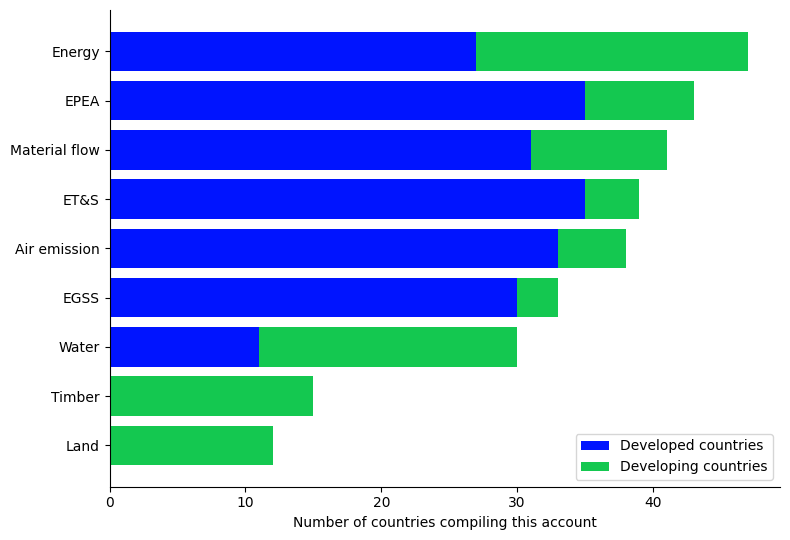

In [3]:

cf = data[data["Group"] == "Central framework (CF)"].set_index("Item")[
    ["Developed countries", "Developing countries"]].fillna(0)
cf = cf.loc[cf.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(cf))
ax.barh(y, cf["Developed countries"], color=color_blue, label="Developed countries")
ax.barh(y, cf["Developing countries"], left=cf["Developed countries"],
        color=color_green, label="Developing countries")
ax.set_yticks(y)
ax.set_yticklabels(cf.index)
ax.set_xlabel("Number of countries compiling this account")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



### 1.2 Ecosystem Accounting coverage

The same breakdown for the newer Ecosystem Accounting (EA) account types
— consistently lower adoption than the Central Framework, and more
concentrated among developed countries.


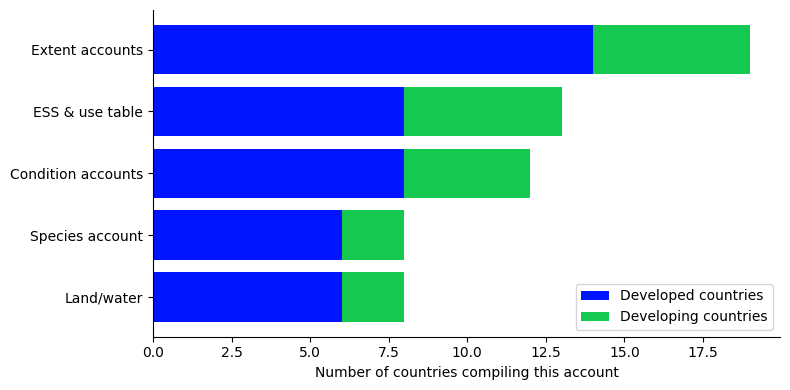

In [4]:

ea = data[data["Group"] == "Ecosystem Accounting (EA)"].set_index("Item")[
    ["Developed countries", "Developing countries"]]
ea = ea.loc[ea.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(ea))
ax.barh(y, ea["Developed countries"], color=color_blue, label="Developed countries")
ax.barh(y, ea["Developing countries"], left=ea["Developed countries"],
        color=color_green, label="Developing countries")
ax.set_yticks(y)
ax.set_yticklabels(ea.index)
ax.set_xlabel("Number of countries compiling this account")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 2. SEEA implementation stage by country

`chap7_seea_map.xlsx` — the country-level data behind the reference world
map: a 4-level implementation-stage code (0 = no implementation through
3 = most advanced) for 202 countries and territories.


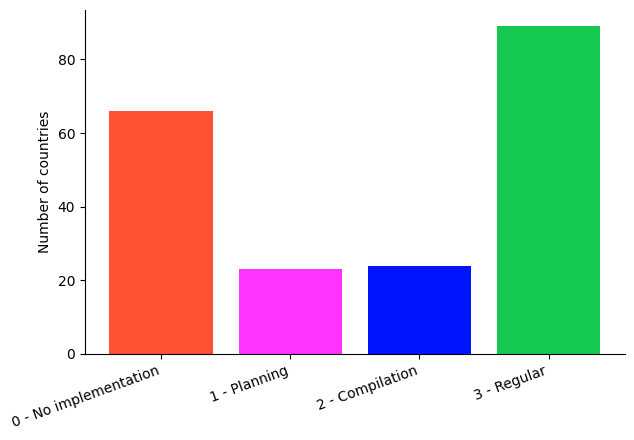

stage
0 - No implementation    66
1 - Planning             23
2 - Compilation          24
3 - Regular              89
Name: count, dtype: int64


In [5]:

geo = pd.read_excel(f"{DATA_DIR}/chap7_seea_map.xlsx", sheet_name="Feuil1", header=0)
geo.columns = ["code", "country", "stage"]

stage_labels = {0: "0 - No implementation", 1: "1 - Planning", 2: "2 - Compilation", 3: "3 - Regular"}
counts = geo["stage"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
colours = [color_red, color_violet, color_blue, color_green]
ax.bar([stage_labels[s] for s in counts.index], counts.values, color=colours)
ax.set_ylabel("Number of countries")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=20, ha="right")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print(counts.rename(index=stage_labels))


In [6]:

print("Countries at the most advanced stage (regular compilation):")
print(geo.loc[geo["stage"] == 3, "country"].sort_values().to_string(index=False))
print()
print("Countries with no SEEA implementation on record:")
print(geo.loc[geo["stage"] == 0, "country"].sort_values().to_string(index=False))


Countries at the most advanced stage (regular compilation):
               Albania
               Armenia
             Australia
               Austria
            Azerbaijan
               Belarus
               Belgium
                Bhutan
Bosnia and Herzegovina
              Botswana
                Brazil
              Bulgaria
               Burundi
              Cameroon
                Canada
                 China
              Colombia
            Costa Rica
               Croatia
                Cyprus
        Czech Republic
               Denmark
    Dominican Republic
               Ecuador
                 Egypt
               Estonia
                  Fiji
               Finland
                France
               Georgia
               Germany
                 Ghana
                Greece
             Guatemala
               Hungary
               Iceland
                 India
             Indonesia
                  Iran
               Ireland
                Isra


## Summary

This notebook works through Chapter 7's two source spreadsheets and
reference map as a standalone data-exploration piece: the UN SEEA
implementation survey by account type and country, and the country-level
implementation-stage data behind the reference map. This is a one-off
pair of survey-table reads, not a generic reusable primitive.
